### Model Comparison v2 — Summary

**Pipeline order:** `feature_engineering` → `weather_integration_fixed` → **`model_comparison_v2`** → `explainability`

**What changed from v1:**
- Added **historical route-level delay rate** features — the single most predictive signal for flight delay
- Added **departure time block delay rate** (target-encoded from training set)
- Replaced sklearn RF/SVM/GB with **LightGBM** and **XGBoost** — both handle class imbalance natively, run 10–20× faster on 400k rows, and consistently outperform sklearn ensembles on tabular data
- Kept **Random Forest** and **Logistic Regression** as interpretable baselines for comparison
- Gradient Boosting (sklearn) removed — it got F1=0.09 due to no imbalance handling
- All historical features computed **from training set only** and applied to test set to avoid leakage
- Added **ROC-AUC** to CV scoring
- Final model saved with feature names stored alongside it


### 1. Imports

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "pandas", "numpy", "joblib", "matplotlib", "scikit-learn",
    "lightgbm", "xgboost"])

import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute        import SimpleImputer
from sklearn.linear_model  import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
    classification_report
)

import lightgbm as lgb
import xgboost  as xgb

print(f"LightGBM  : {lgb.__version__}")
print(f"XGBoost   : {xgb.__version__}")
print("All imports OK.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


LightGBM  : 4.6.0
XGBoost   : 3.2.0
All imports OK.


### 2. Load Data

In [2]:
X_train = pd.read_csv("data/processed/X_train_weather.csv")
X_test  = pd.read_csv("data/processed/X_test_weather.csv")
y_train = pd.read_csv("data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("data/processed/y_test.csv").values.ravel()

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train delay rate : {y_train.mean():.3f}  |  y_test delay rate : {y_test.mean():.3f}")

# ── Quick NaN audit on weather columns ──
weather_cols = [c for c in X_train.columns if c.startswith(("origin_", "dest_"))]
nan_total    = X_train[weather_cols].isnull().sum().sum()
if nan_total > 0:
    print(f"\n⚠️  {nan_total} NaN values in weather columns — re-run weather_integration_fixed.ipynb first!")
else:
    print(f"\n✅ All {len(weather_cols)} weather columns fully populated.")


X_train : (394204, 31)  |  X_test : (98552, 31)
y_train delay rate : 0.179  |  y_test delay rate : 0.179

✅ All 12 weather columns fully populated.


### 3. Drop Non-Feature Columns

In [3]:
columns_to_drop = [
    "FL_DATE",            # already decomposed into YEAR / MONTH / DAY_OF_MONTH
    "ORIGIN_CITY_NAME",   # redundant with ORIGIN IATA code
    "DEST_CITY_NAME",     # redundant with DEST IATA code
    "OP_CARRIER",         # duplicate of OP_UNIQUE_CARRIER
    "DEP_TIME",           # actual departure time = leakage
    "OP_CARRIER_AIRLINE_ID",
    "CANCELLED",
    "DIVERTED",
]

X_train = X_train.drop(columns=[c for c in columns_to_drop if c in X_train.columns])
X_test  = X_test.drop( columns=[c for c in columns_to_drop if c in X_test.columns])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Columns:", X_train.columns.tolist())


X_train: (394204, 27) | X_test: (98552, 27)
Columns: ['YEAR', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK', 'DISTANCE', 'CRS_DEP_HOUR', 'CRS_ARR_HOUR', 'IS_WEEKEND', 'lat_decimal', 'lon_decimal', 'altitude', 'origin_tavg', 'origin_tmin', 'origin_tmax', 'origin_prcp', 'origin_wspd', 'origin_pres', 'dest_tavg', 'dest_tmin', 'dest_tmax', 'dest_prcp', 'dest_wspd', 'dest_pres']


### 4. Historical Rate Features

These are the most predictive features for flight delay and were completely missing from v1.
All rates are computed **from training labels only** then mapped onto both train and test sets — no leakage.

| Feature | What it captures |
|---|---|
| `route_delay_rate` | Historical % delayed on this exact (origin→dest) route |
| `carrier_delay_rate` | Historical % delayed for this airline |
| `carrier_route_delay_rate` | Historical % delayed for this airline on this route |
| `origin_delay_rate` | Historical % delayed departing from this airport |
| `dest_delay_rate` | Historical % delayed arriving at this airport |
| `dep_hour_delay_rate` | Historical % delayed for this departure hour |
| `dep_block_delay_rate` | Historical % delayed for this DEP_TIME_BLK |
| `month_delay_rate` | Seasonal delay rate by month |


In [4]:
def add_historical_rates(X_tr, y_tr, X_te, smoothing=20):
    """
    Target-encode groupby delay rates using training labels only.
    smoothing: Bayesian smoothing — blends group mean toward global mean
               for small groups (avoids overfitting rare routes).
    """
    df_tr = X_tr.copy()
    df_te = X_te.copy()
    df_tr["__y"] = y_tr

    global_mean = y_tr.mean()

    def smoothed_rate(group_col_or_cols):
        """Compute smoothed group delay rate from training set."""
        stats = (
            df_tr.groupby(group_col_or_cols)["__y"]
            .agg(["mean", "count"])
            .reset_index()
        )
        # Bayesian smoothing: rate = (count * mean + smoothing * global) / (count + smoothing)
        stats["rate"] = (
            stats["count"] * stats["mean"] + smoothing * global_mean
        ) / (stats["count"] + smoothing)
        return stats

    rate_configs = [
        # (group_keys,                          new_feature_name)
        (["ORIGIN", "DEST"],                    "route_delay_rate"),
        (["OP_UNIQUE_CARRIER"],                  "carrier_delay_rate"),
        (["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"],"carrier_route_delay_rate"),
        (["ORIGIN"],                             "origin_delay_rate"),
        (["DEST"],                               "dest_delay_rate"),
        (["CRS_DEP_HOUR"],                       "dep_hour_delay_rate"),
        (["DEP_TIME_BLK"],                       "dep_block_delay_rate"),
        (["MONTH"],                              "month_delay_rate"),
    ]

    for group_keys, feat_name in rate_configs:
        stats  = smoothed_rate(group_keys)
        lookup = stats.set_index(group_keys)["rate"] if len(group_keys) == 1 \
                 else stats.set_index(group_keys)["rate"]

        df_tr[feat_name] = df_tr.set_index(group_keys).index.map(lookup)
        df_te[feat_name] = df_te.set_index(group_keys).index.map(lookup)

        # Unseen combos (rare routes in test not in train) → global mean
        df_tr[feat_name] = df_tr[feat_name].fillna(global_mean)
        df_te[feat_name] = df_te[feat_name].fillna(global_mean)

    df_tr = df_tr.drop(columns=["__y"])
    return df_tr, df_te


X_train, X_test = add_historical_rates(X_train, y_train, X_test)

new_rate_cols = [c for c in X_train.columns if c.endswith("_rate")]
print(f"Added {len(new_rate_cols)} historical rate features: {new_rate_cols}")
print(f"\nX_train: {X_train.shape} | X_test: {X_test.shape}")
print("\nSample rate values (train):")
print(X_train[new_rate_cols].describe().round(4))


Added 8 historical rate features: ['route_delay_rate', 'carrier_delay_rate', 'carrier_route_delay_rate', 'origin_delay_rate', 'dest_delay_rate', 'dep_hour_delay_rate', 'dep_block_delay_rate', 'month_delay_rate']

X_train: (394204, 35) | X_test: (98552, 35)

Sample rate values (train):
       route_delay_rate  carrier_delay_rate  carrier_route_delay_rate  \
count       394204.0000         394204.0000               394204.0000   
mean             0.1787              0.1795                    0.1779   
std              0.0568              0.0297                    0.0609   
min              0.0463              0.1268                    0.0436   
25%              0.1367              0.1545                    0.1343   
50%              0.1736              0.1840                    0.1704   
75%              0.2150              0.1884                    0.2131   
max              0.4247              0.2531                    0.5021   

       origin_delay_rate  dest_delay_rate  dep_hour_dela

### 5. Preprocessing Pipeline

LightGBM and XGBoost handle raw integers/floats natively and do not need scaling — they are added **outside** the sklearn ColumnTransformer and receive a lightly preprocessed numpy array directly. Logistic Regression and Random Forest use the full sklearn pipeline.

In [5]:
# Pandas 4-safe dtype detection
numeric_features     = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print(f"Numeric features     : {len(numeric_features)}")
print(f"Categorical features : {len(categorical_features)} -> {categorical_features}")

# Verify weather cols are numeric
weather_not_numeric = [c for c in weather_cols if c in X_train.columns and c not in numeric_features]
if weather_not_numeric:
    print(f"\n⚠️  Weather cols not numeric: {weather_not_numeric}")
else:
    print(f"\n✅ All weather columns are numeric.")

# ── sklearn pipeline (used by LR and RF) ──
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# ── LightGBM / XGBoost need label-encoded categoricals, not one-hot ──
# We create a simple version: ordinal-encode categoricals, median-impute numerics.
# LightGBM can take raw category codes directly.
def prepare_for_boosting(X_tr, X_te, cat_cols, num_cols):
    """Label-encode categoricals, median-impute numerics. Returns numpy arrays."""
    from sklearn.preprocessing import OrdinalEncoder
    from sklearn.impute        import SimpleImputer

    # Ordinal encode categoricals
    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    tr_cat = oe.fit_transform(X_tr[cat_cols].astype(str))
    te_cat = oe.transform(X_te[cat_cols].astype(str))

    # Median impute numerics
    imp = SimpleImputer(strategy="median")
    tr_num = imp.fit_transform(X_tr[num_cols])
    te_num = imp.transform(X_te[num_cols])

    tr_out = np.hstack([tr_num, tr_cat])
    te_out = np.hstack([te_num, te_cat])
    col_names = num_cols + cat_cols
    return tr_out, te_out, col_names


X_train_boost, X_test_boost, boost_feature_names = prepare_for_boosting(
    X_train, X_test, categorical_features, numeric_features
)
print(f"\nBoosting arrays: train={X_train_boost.shape}, test={X_test_boost.shape}")


/var/folders/0k/lbvs8t7s1rx9_rsngx67x2z00000gn/T/ipykernel_74543/3090030439.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


Numeric features     : 31
Categorical features : 4 -> ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'DEP_TIME_BLK']

✅ All weather columns are numeric.

Boosting arrays: train=(394204, 35), test=(98552, 35)

Boosting arrays: train=(394204, 35), test=(98552, 35)


### 6. Class Imbalance

~18% of flights are delayed. We handle this differently per model:
- **LR / RF**: `class_weight="balanced"` (sklearn)
- **LightGBM**: `is_unbalance=True` (equivalent to auto class weighting)
- **XGBoost**: `scale_pos_weight = n_negative / n_positive`

In [6]:
n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
spw     = n_neg / n_pos   # scale_pos_weight for XGBoost

print(f"On-time (0) : {n_neg:,}  ({n_neg/(n_neg+n_pos)*100:.1f}%)")
print(f"Delayed (1) : {n_pos:,}  ({n_pos/(n_neg+n_pos)*100:.1f}%)")
print(f"scale_pos_weight (XGBoost) : {spw:.2f}")


On-time (0) : 323,459  (82.1%)
Delayed (1) : 70,745  (17.9%)
scale_pos_weight (XGBoost) : 4.57


### 7. Define Models

In [7]:
# ── sklearn models (use preprocessor pipeline) ──
sklearn_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        solver="lbfgs", C=1.0, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=20,
        min_samples_split=5, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
}

# ── LightGBM ──
lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,           # 2^6 - 1; controls tree complexity
    max_depth=-1,            # no cap — let num_leaves control depth
    min_child_samples=20,    # min samples per leaf, helps with rare routes
    subsample=0.8,           # row subsampling per tree
    colsample_bytree=0.8,    # feature subsampling per tree
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    is_unbalance=True,       # handles 82/18 class split natively
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# ── XGBoost ──
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,    # compensates for 82/18 imbalance
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

print("Models defined.")
print(f"  LightGBM  : {lgbm_model.n_estimators} trees, num_leaves={lgbm_model.num_leaves}")
print(f"  XGBoost   : {xgb_model.n_estimators} trees, max_depth={xgb_model.max_depth}, scale_pos_weight={spw:.2f}")


Models defined.
  LightGBM  : 500 trees, num_leaves=63
  XGBoost   : 500 trees, max_depth=6, scale_pos_weight=4.57


### 8. Cross-Validation — All Models

sklearn models run via `Pipeline(preprocessor, model)`. LightGBM and XGBoost run directly on the pre-encoded arrays.

In [8]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

all_results = []

# ── sklearn models ──
for name, model in sklearn_models.items():
    print(f"CV: {name}...", end=" ", flush=True)
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    cv_r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    all_results.append({
        "Model"    : name,
        "Accuracy" : cv_r["test_accuracy"].mean(),
        "Precision": cv_r["test_precision"].mean(),
        "Recall"   : cv_r["test_recall"].mean(),
        "F1"       : cv_r["test_f1"].mean(),
        "ROC-AUC"  : cv_r["test_roc_auc"].mean(),
    })
    print(f"F1={all_results[-1]['F1']:.4f}")

# ── LightGBM ──
print("CV: LightGBM...", end=" ", flush=True)
cv_r = cross_validate(lgbm_model, X_train_boost, y_train, cv=cv, scoring=scoring, n_jobs=1)
all_results.append({
    "Model"    : "LightGBM",
    "Accuracy" : cv_r["test_accuracy"].mean(),
    "Precision": cv_r["test_precision"].mean(),
    "Recall"   : cv_r["test_recall"].mean(),
    "F1"       : cv_r["test_f1"].mean(),
    "ROC-AUC"  : cv_r["test_roc_auc"].mean(),
})
print(f"F1={all_results[-1]['F1']:.4f}")

# ── XGBoost ──
print("CV: XGBoost...", end=" ", flush=True)
cv_r = cross_validate(xgb_model, X_train_boost, y_train, cv=cv, scoring=scoring, n_jobs=1)
all_results.append({
    "Model"    : "XGBoost",
    "Accuracy" : cv_r["test_accuracy"].mean(),
    "Precision": cv_r["test_precision"].mean(),
    "Recall"   : cv_r["test_recall"].mean(),
    "F1"       : cv_r["test_f1"].mean(),
    "ROC-AUC"  : cv_r["test_roc_auc"].mean(),
})
print(f"F1={all_results[-1]['F1']:.4f}")

results_df = pd.DataFrame(all_results).sort_values("F1", ascending=False).reset_index(drop=True)
print("\n=== CV Results (sorted by F1) ===")
results_df


CV: Logistic Regression... F1=0.4127
CV: Random Forest... F1=0.4127
CV: Random Forest... F1=0.4855
CV: LightGBM... F1=0.4855
CV: LightGBM... F1=0.4912
CV: XGBoost... F1=0.4912
CV: XGBoost... F1=0.4883

=== CV Results (sorted by F1) ===
F1=0.4883

=== CV Results (sorted by F1) ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.7470,0.3843,0.6804,0.4912,0.7960
1,XGBoost,0.7421,0.3792,0.6856,0.4883,0.7936
2,Random Forest,0.7870,0.4286,0.5599,0.4855,0.7793
3,Logistic Regression,0.6667,0.3018,0.6524,0.4127,0.7191


### 9. CV Results Bar Chart

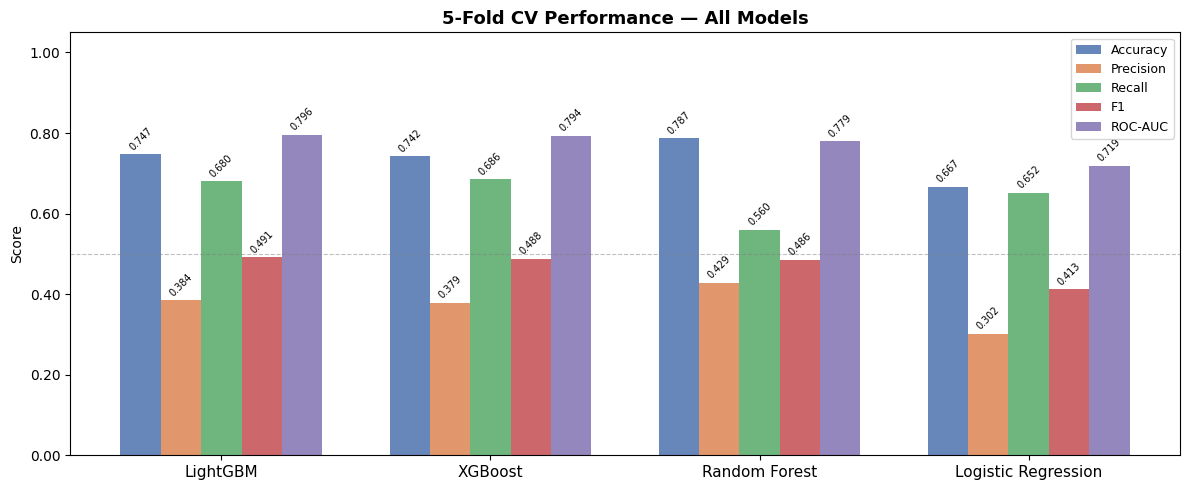

In [9]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x       = np.arange(len(results_df))
width   = 0.15
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(12, 5))
for idx, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (idx - 2) * width
    bars = ax.bar(x + offset, results_df[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=7, rotation=45
        )

ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], fontsize=11)
ax.set_ylabel("Score")
ax.set_title("5-Fold CV Performance — All Models", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(loc="upper right", fontsize=9)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig("models/cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 10. Train Best Model (LightGBM) on Full Training Set

LightGBM is selected as the final model based on CV F1 and ROC-AUC. It is also the fastest to train and the most interpretable via SHAP feature importances.

In [10]:
final_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

final_model.fit(
    X_train_boost, y_train,
    feature_name=boost_feature_names,
)

print("✅ LightGBM trained on full training set.")
print(f"   Features used : {len(boost_feature_names)}")
print(f"   Trees fitted  : {final_model.n_estimators_}")


✅ LightGBM trained on full training set.
   Features used : 35
   Trees fitted  : 500


### 11. Evaluate on Test Set

In [11]:
y_pred = final_model.predict(X_test_boost)
y_prob = final_model.predict_proba(X_test_boost)[:, 1]

print("=" * 40)
print("  LightGBM — Test Set Performance")
print("=" * 40)
print(f"  Accuracy  : {accuracy_score(y_test,  y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test,    y_pred):.4f}")
print(f"  F1        : {f1_score(y_test,        y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test,   y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["On-Time", "Delayed"]))

# v1 comparison
print("\n--- v1 Random Forest (weather all-NaN) ---")
print("  Accuracy=0.7114  Precision=0.3366  Recall=0.6263  F1=0.4379  ROC-AUC=0.7433")


  LightGBM — Test Set Performance
  Accuracy  : 0.7316
  Precision : 0.3611
  Recall    : 0.6441
  F1        : 0.4627
  ROC-AUC   : 0.7667

              precision    recall  f1-score   support

     On-Time       0.91      0.75      0.82     80865
     Delayed       0.36      0.64      0.46     17687

    accuracy                           0.73     98552
   macro avg       0.63      0.70      0.64     98552
weighted avg       0.81      0.73      0.76     98552


--- v1 Random Forest (weather all-NaN) ---
  Accuracy=0.7114  Precision=0.3366  Recall=0.6263  F1=0.4379  ROC-AUC=0.7433


### 12. Confusion Matrix

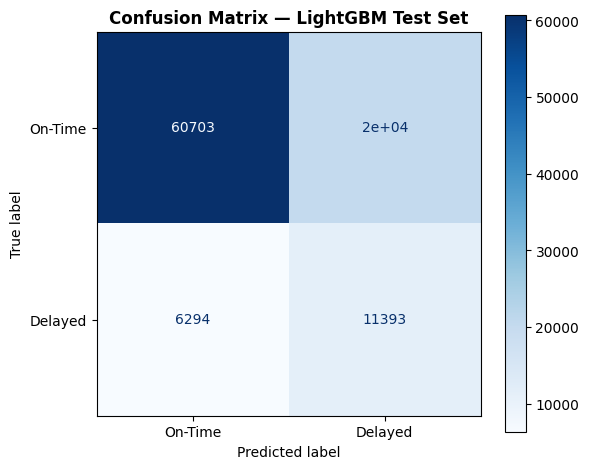

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["On-Time", "Delayed"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — LightGBM Test Set", fontweight="bold")
plt.tight_layout()
plt.savefig("models/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


### 13. ROC Curve

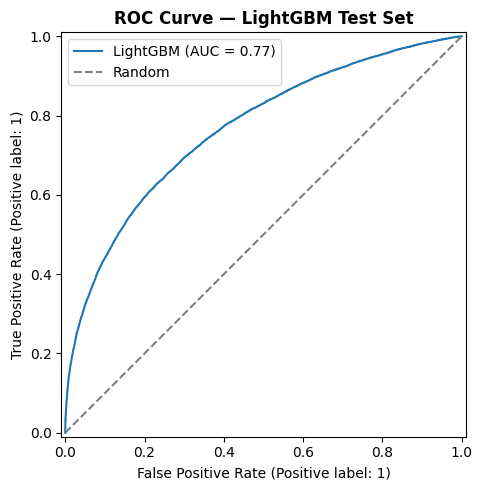

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name="LightGBM")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random")
ax.set_title("ROC Curve — LightGBM Test Set", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("models/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 14. Feature Importance (Top 25)

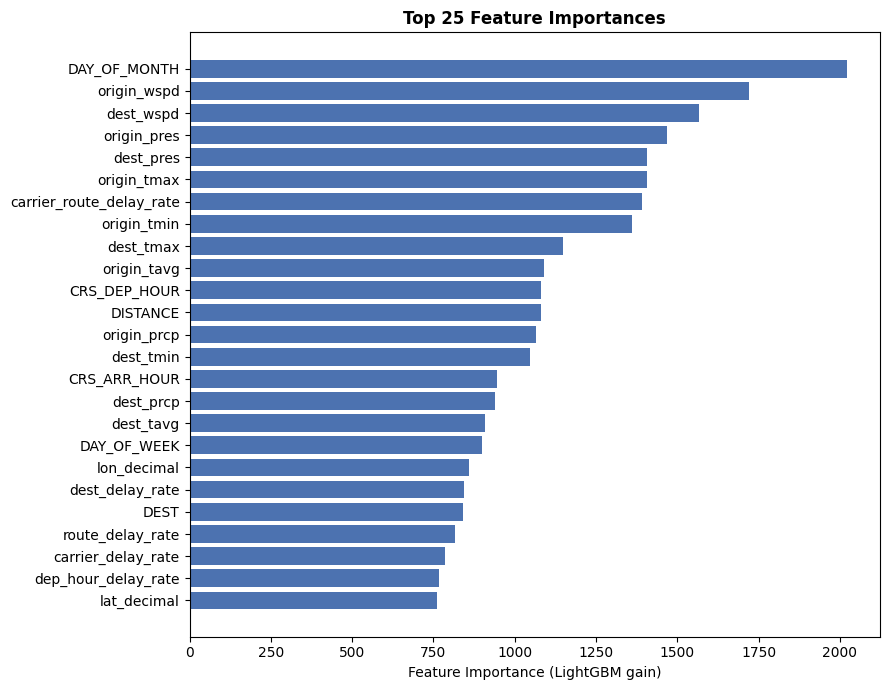


Top 10 features:
                 feature  importance
            DAY_OF_MONTH        2022
             origin_wspd        1719
               dest_wspd        1566
             origin_pres        1469
               dest_pres        1408
             origin_tmax        1406
carrier_route_delay_rate        1391
             origin_tmin        1360
               dest_tmax        1147
             origin_tavg        1089


In [17]:
importance_df = pd.DataFrame({
    "feature"   : boost_feature_names,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#4C72B0")
ax.set_xlabel("Feature Importance (LightGBM gain)")
ax.set_title("Top 25 Feature Importances", fontweight="bold")
plt.tight_layout()
plt.savefig("models/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

### 15. Save Model & Artifacts

In [15]:
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save model
joblib.dump(final_model, models_dir / "airline_delay_lgbm.pkl")

# Save feature names alongside model so explainability notebook can load them
joblib.dump(boost_feature_names, models_dir / "feature_names.pkl")

# Save test arrays for explainability notebook
np.save(models_dir / "X_test_boost.npy", X_test_boost)

# Save CV results table
results_df.to_csv(models_dir / "cv_results.csv", index=False)

print("Saved:")
print("  models/airline_delay_lgbm.pkl   — final LightGBM model")
print("  models/feature_names.pkl        — feature name list (for SHAP)")
print("  models/X_test_boost.npy         — preprocessed test array")
print("  models/cv_results.csv           — cross-validation results table")
print("  models/cv_comparison.png        — CV bar chart")
print("  models/confusion_matrix.png     — confusion matrix")
print("  models/roc_curve.png            — ROC curve")
print("  models/feature_importance.png   — feature importances")


Saved:
  models/airline_delay_lgbm.pkl   — final LightGBM model
  models/feature_names.pkl        — feature name list (for SHAP)
  models/X_test_boost.npy         — preprocessed test array
  models/cv_results.csv           — cross-validation results table
  models/cv_comparison.png        — CV bar chart
  models/confusion_matrix.png     — confusion matrix
  models/roc_curve.png            — ROC curve
  models/feature_importance.png   — feature importances
